<a href="https://colab.research.google.com/github/Cxris2145/MineriaDatos2026/blob/main/ExportacionesChile2026Mejorado3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

---

| | |
|---|---|
| **Grupo** | Grupo 1 |
| **Sección** | 002D |
| **Integrantes** | Christopher Guerrero · Luis Faundes |
| **Correos** | lu.faundes@duocuc.cl · ch.guerrerod@duocuc.cl |
| **Fecha** | Mayo 2026 |
| **Dataset** | Chile Export Products 2017–2021 |
| **Fuente** | [Kaggle — Chile Export Products](https://www.kaggle.com/datasets/michallublin/chile-export-products-20172021) |
| **Fuente Profesor** | [Github profesor](https://github.com/UXDynamicSolution/MineriaDatosDuocPAO/tree/main) |
| **Github Grupo** | [Github Nosotros](https://github.com/Cxris2145/MineriaDatos2026) |

---

</div>

---
# Ítem 1: Importación de Bibliotecas

En esta sección se cargan todas las librerías necesarias para el análisis.  
Esto debe ejecutarse **primero** antes de cualquier otra celda del notebook.

| Librería | Uso principal |
|---|---|
| `pandas` | Manipulación y análisis de datos en tablas |
| `numpy` | Operaciones matemáticas y manejo de arrays |
| `seaborn` | Visualizaciones estadísticas de alto nivel |
| `matplotlib` | Gráficos personalizados y configuración visual |
| `sklearn` | Modelos de Machine Learning y métricas |
| `scipy` | Pruebas estadísticas como la correlación de Pearson |


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [2]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas
pd.set_option('display.max_rows', None)


#***Análisis de Exportaciones de Chile (2017 - 2021)***



Este proyecto realiza un análisis exploratorio del dataset **"ChileExport.csv"**, el cual documenta la actividad comercial de Chile con el exterior. El conjunto de datos permite segmentar la información bajo los siguientes criterios:



* **Ejes Geográficos:** Identificación de más de 220 países de destino.

* **Clasificación Sectorial:** División entre productos Mineros y No Mineros (Agropecuarios, Forestales, Servicios, etc.).



* **Métricas de Valor:** Registro de ingresos anuales en USD para evaluar el impacto económico de cada producto.



**Objetivo:** Procesar los datos nominales y cuantitativos para identificar tendencias comerciales y la composición de la matriz exportadora nacional en los últimos 5 años

#**Mapeo de tablas**

country: Categórico | Nominal | Son nombres de paises, no tienen orden

1_category:  Categórico | Nominal | Clasficación genreal, no tiene jerarquia numérica

2_category: Categórico | Nominal | Subcategoría, sigue siendo solo etiqueta

Product: Categórico | Nominal | Nombre del producto, no se puede ordenar

year: Numérico | Intervalo | Tiene orden y diferecias iguales, pero no cero absoluto

income_in_USD: Numérico | Ratio | Tiene cero real y permite proporcones

#**Descripción de las columnas del dataset**

Country: País al que se exporta el producto

1 category: Indica si la exportación es minera o no minera

2 category: Tipo de producto o sector (frutas, minería, alimentos, etc.)

Product: Producto específico exportado

Year: Año en que se realizó la exportación

Income in USD: Monto de dinero generado por la exportación en dólares


---
# Ítem 2: Carga del Dataset

Se carga el archivo `ChileExport.csv` que contiene los registros de exportaciones de Chile entre 2017 y 2021.  
`df.head()` muestra las primeras 5 filas para verificar que los datos se cargaron correctamente.


In [3]:
df = pd.read_csv("ChileExport.csv", sep=';')
df.head()

,Country,1 category,2 category,Product,Year,Income in USD
0,China,Minero,Minería,Minerales de cobre y sus concentrados,2017,6470444174
1,China,Minero,Minería,Cobre,2017,7604230274
2,China,Minero,Minería,Minerales de hierro y sus concentrados,2017,"616711446,1"
3,China,Minero,Minería,Litio,2017,234218255
4,China,Minero,Minería,Minerales de molibdeno y sus concentrados,2017,"37490057,93"


---
# Ítem 3: Limpieza de Datos

Antes de analizar, es necesario limpiar la columna `Income in USD` ya que viene en formato europeo  
(puntos como separadores de miles y comas como decimales). Se convierte al formato numérico estándar  
y se verifican valores nulos que puedan afectar los análisis posteriores.


In [4]:
# Limpieza de datos

df['Income in USD'] = df['Income in USD'].astype(str).str.strip()

# Eliminación de los puntos que separan los miles (ej: 1.500 -> 1500)
df['Income in USD'] = df['Income in USD'].str.replace('.', '', regex=False)

# Cambiamos la coma decimal por un punto (ej: 1500,50 -> 1500.50)
df['Income in USD'] = df['Income in USD'].str.replace(',', '.', regex=False)

# Se transforma a número
df['Income in USD'] = pd.to_numeric(df['Income in USD'], errors='coerce')

# ELIMINACIÓN DE REGISTROS EN BLANCO
# Quitamos las filas que no tienen categoría definida (los 15 registros vacíos)
df = df[df['1 category'] != '(en blanco)']

# Verificamos nulos finales
print(f"Valores nulos finales: {df['Income in USD'].isnull().sum()}")
print(f"Registros restantes después de limpiar blancos: {len(df)}")

Valores nulos finales: 0
Registros restantes después de limpiar blancos: 21370


Se limpian también los nombres de columnas por si tienen espacios ocultos que puedan causar errores al referenciarlas.

In [5]:
# Limpiamos los nombres de columnas por si tienen espacios raros
df.columns = df.columns.str.strip()

Se eliminan filas duplicadas para evitar que registros repetidos distorsionen los resultados del análisis.

In [6]:
# Revisamos si hay filas duplicadas en el dataset (datos repetidos)
df.duplicated().sum()

# Eliminamos duplicados si existen
df = df.drop_duplicates()

---
# Ítem 4: Exploración Inicial del Dataset

En esta etapa realizamos una exploración inicial del dataset. Revisamos cuántas filas y columnas tiene, qué tipos de datos contiene, si existen valores nulos y si los nombres de las columnas están correctos. Esta parte es importante porque nos permite conocer la calidad de los datos antes de limpiarlos, analizarlos y aplicar el modelo de Machine Learning.


`df.shape` muestra la cantidad total de filas y columnas del dataset.

In [7]:
df.shape

(21370, 6)

`df.dtypes` indica el tipo de dato de cada columna (texto, número, etc.).

In [8]:
df.dtypes

,0
Country,object
1 category,object
2 category,object
Product,object
Year,int64
Income in USD,float64


`df.columns` lista los nombres exactos de todas las columnas disponibles.

In [9]:
df.columns

Index(['Country', '1 category', '2 category', 'Product', 'Year',
       'Income in USD'],
      dtype='object')

`df.isnull().sum()` cuenta cuántos valores vacíos hay por columna. Esto permite decidir si se deben rellenar o eliminar esos registros.

In [10]:
df.isnull().sum()

,0
Country,0
1 category,0
2 category,0
Product,0
Year,0
Income in USD,0


`df.tail()`
Muestra las últimas filas del dataset.
Sirve para revisar cómo terminan los datos dentro del archivo.
Nos ayuda a comprobar que los registros finales también estén cargados correctamente.
Es útil para detectar si al final del dataset hay filas vacías, errores o datos incompletos.

In [11]:
df.tail()

,Country,1 category,2 category,Product,Year,Income in USD
21380,Gambia,No minero,Exportación de servicios calificados por Aduanas,Exportación de servicios calificados por Aduanas,2021,0.0
21381,Gambia,No minero,Resto No minería,Resto No minería,2021,0.0
21382,Groenlandia,No minero,Resto No minería,Resto No minería,2021,0.0
21383,República de Yemen,No minero,Resto No minería,Resto No minería,2021,0.0
21384,Timor Oriental,No minero,Resto No minería,Resto No minería,2021,0.0


`describe()` sobre la columna `Year` entrega un resumen estadístico: mínimo, máximo, promedio y distribución de los años disponibles.

In [12]:
df_anio = df["Year"].describe()
print(df_anio)

count    21370.000000
mean      2019.000000
std          1.414247
min       2017.000000
25%       2018.000000
50%       2019.000000
75%       2020.000000
max       2021.000000
Name: Year, dtype: float64


Este código cuenta cuántas veces aparece cada país en la columna Country y muestra el resultado en pantalla.

In [13]:
# Estados Unidos de América tuvo más transacciones o diversidad de productos exportados entre 2017 y 2021,
# seguido muy de cerca por China.

df_country = df["Country"].value_counts()
print(df_country)

Country
China                                                  350
Estados Unidos de América                              350
Japón                                                  335
Perú                                                   335
Brasil                                                 330
Canadá                                                 330
España                                                 330
Alemania                                               315
México                                                 310
Colombia                                               310
Holanda                                                305
Corea del Sur                                          305
Italia                                                 300
Reino Unido                                            295
Argentina                                              295
Bélgica                                                280
Ecuador                                         

Se revisa cuántos registros corresponden a exportaciones **mineras vs. no mineras** (primera categoría).

In [14]:
# Revisamos cuántos registros corresponden a exportaciones mineras vs. no mineras
# Ahora que limpiamos los datos, ya no deberían aparecer registros '(en blanco)'
df_category1 = df["1 category"].value_counts()
print(df_category1)

1 category
No minero    19505
Minero        1865
Name: count, dtype: int64


Se revisa la distribución de la **segunda categoría**, que representa subsectores como frutas, minería, alimentos, etc.

In [15]:
df_country = df["2 category"].value_counts()
print(df_country)

2 category
Frutas y frutos                                     5440
Otros alimentos                                     3345
Productos del mar                                   2855
Forestales y sus derivados                          2150
Otros productos relevantes                          2040
Minería                                             1865
Vitivinícola                                        1815
Resto No minería                                    1060
Exportación de servicios calificados por Aduanas     800
Name: count, dtype: int64


Se listan todos los **productos** exportados y su frecuencia.

**Nota:** Esto mide la cantidad de registros (presencia), no el valor monetario. Ayuda a identificar qué productos tienen mayor diversidad de transacciones.

In [16]:
# Listado de productos según su frecuencia de aparición en el dataset
# Verificamos que los productos '(en blanco)' hayan desaparecido
df_products = df["Product"].value_counts()
print(df_products.head(20)) # Mostramos solo el top 20 para limpieza visual

Product
Resto No minería                                    1060
Vinos                                                840
Exportación de servicios calificados por Aduanas     800
Madera y sus manufacturas                            645
Resto Forestales y sus derivados                     620
Papel y cartón y sus manufacturas                    605
Uvas                                                 600
Conservas y preparaciones de pescados y mariscos     590
Resto Otros alimentos                                590
Vinos espumosos                                      580
Manzanas                                             500
Ciruelas                                             490
Salmones y truchas                                   470
Nueces de nogal                                      460
Medicamentos                                         445
Kiwis                                                410
Mostos de uva                                        395
Resto Frutas y frutos  

---
# Ítem 5: Análisis con Gráficos (EDA)

En esta parte usamos **gráficos** para entender la información de forma visual y sencilla.

Esto nos sirve para responder preguntas clave como:
* **¿Qué vendemos más?** (Sectores y productos).
* **¿A quién le vendemos?** (Países principales).
* **¿Estamos mejorando?** (Cómo cambian las ventas con el paso de los años).

Cada gráfico tiene una pequeña explicación para que cualquiera pueda entender los resultados sin ser experto en datos.

Se crea la función `agregar_valores()` para mostrar automáticamente el número exacto sobre cada barra de los gráficos.

In [17]:
# Esta función sirve para poner los valores encima de cada barra del gráfico
def agregar_valores(ax):
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom')

### 5.1 Distribución por Categoría Principal
**Gráfico de barras:** Compara visualmente la cantidad de registros entre exportaciones mineras y no mineras.

Este gráfico muestra cuántas exportaciones pertenecen al sector minero y cuántas al resto de sectores.
Sirve para entender qué tipo de exportación aparece más en los datos. Por ejemplo, si hay muchas más exportaciones no mineras, significa que hay más variedad de productos fuera de la minería, aunque eso no necesariamente significa que generen más dinero.

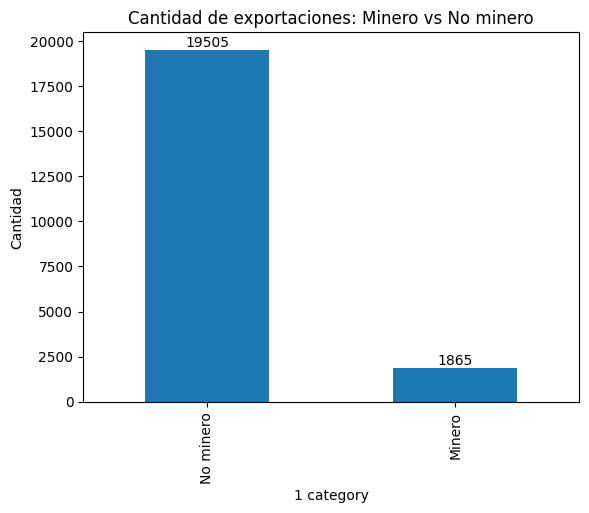

In [18]:
ax = df['1 category'].value_counts().plot(kind='bar')

plt.title("Cantidad de exportaciones: Minero vs No minero")
plt.ylabel("Cantidad")

agregar_valores(ax)

plt.show()

**Gráfico de distribución (torta):** Muestra la proporción porcentual de exportaciones mineras vs. no mineras, permitiendo entender el peso relativo de cada sector.

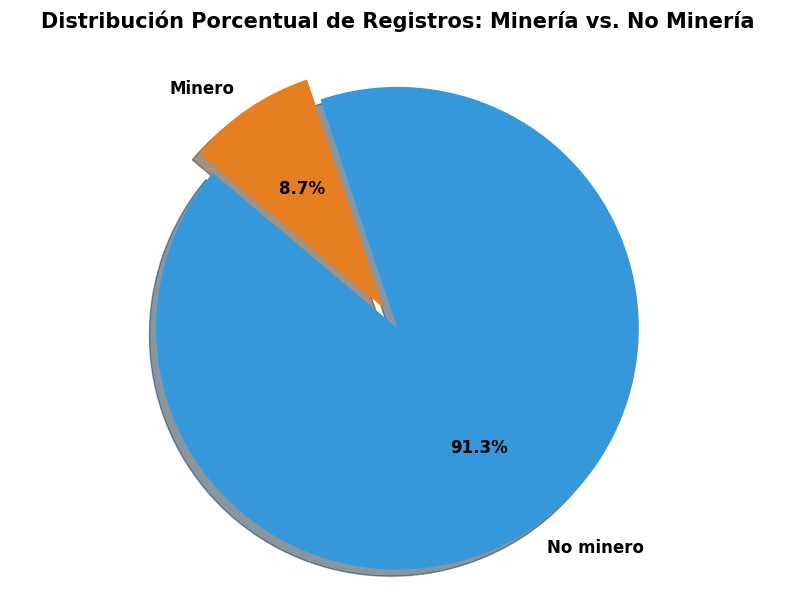

In [19]:
import matplotlib.pyplot as plt

# 1. Preparamos los datos contando las frecuencias de la categoría principal
data_torta = df['1 category'].value_counts()

# 2. Configuración estética superior
plt.figure(figsize=(10, 7))
# 'explode' separa un poco las tajadas para resaltar (0.1 para la segunda categoría)
explode = [0, 0.1] if len(data_torta) == 2 else [0] * len(data_torta)

# 3. Creamos el gráfico mejorado
plt.pie(data_torta,
        labels=data_torta.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=['#3498db', '#e67e22', '#95a5a6'],
        explode=explode,
        shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title("Distribución Porcentual de Registros: Minería vs. No Minería", fontsize=15, fontweight='bold', pad=20)
plt.axis('equal')  # Para que el gráfico sea un círculo perfecto

plt.show()

# EXPLICACIÓN MEJORADA:
# Este gráfico de torta muestra la composición de la base de datos por frecuencia de registros.
# - Notamos que el sector 'No minero' abarca la gran mayoría de las transacciones (91.3%).
# - El sector 'Minero' representa una porción menor en cantidad de envíos (8.7%), lo que resalta
#   su naturaleza de 'pocos envíos pero de altísimo valor' comparado con el resto de la economía.

### 5.2 Análisis por Subsector (Segunda Categoría)

**Gráfico de barras:** Muestra la distribución de registros entre los distintos subsectores, revelando qué tipos de productos tienen más transacciones registradas.

**Información Adicional:**
* **Diversidad Exportadora:** Sectores como *Frutas y frutos* y *Otros alimentos* lideran en cantidad de operaciones. Esto indica que Chile tiene una base exportadora muy atomizada y activa en el rubro agroindustrial.
* **Frecuencia vs. Valor:** Notarás que la *Minería* no es el primer lugar en cantidad de registros. Esto sucede porque una sola exportación minera puede valer lo mismo que cientos de envíos de frutas, por lo que la minería es de 'baja frecuencia pero alto valor'.

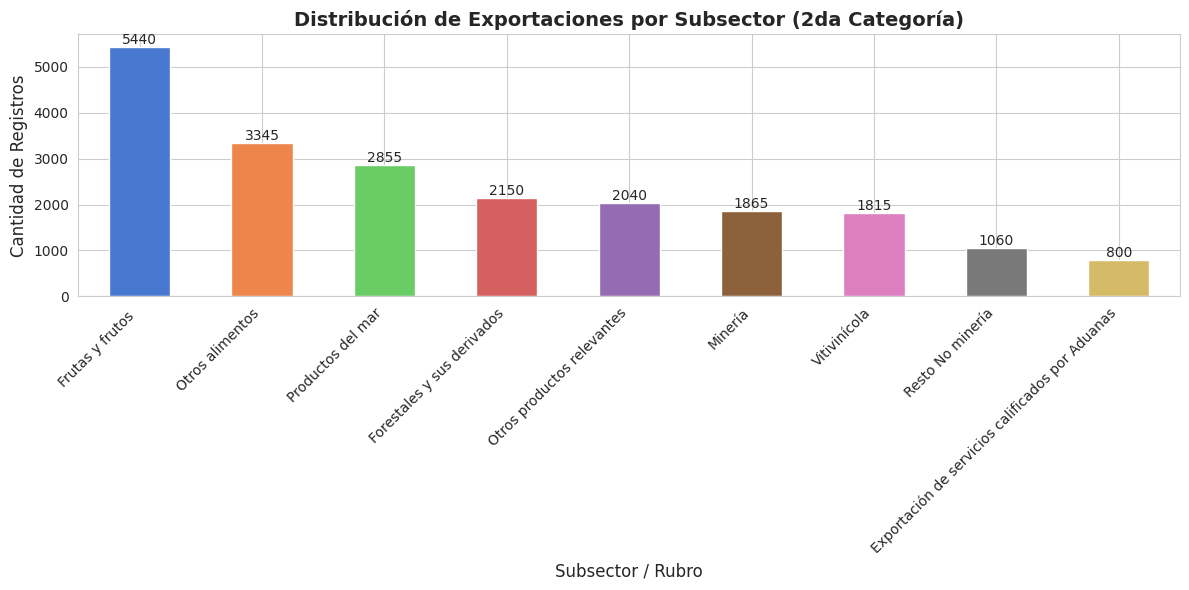

In [20]:
# 1. Obtenemos los datos de la segunda categoría
data_subsector = df['2 category'].value_counts()

# 2. Configuración del gráfico
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Usamos una paleta de colores variada
ax = data_subsector.plot(kind='bar', color=sns.color_palette('muted'))

# 3. Títulos y etiquetas
plt.title("Distribución de Exportaciones por Subsector (2da Categoría)", fontsize=14, fontweight='bold')
plt.ylabel("Cantidad de Registros", fontsize=12)
plt.xlabel("Subsector / Rubro", fontsize=12)
plt.xticks(rotation=45, ha='right')

# 4. Agregamos los valores sobre las barras
agregar_valores(ax)

plt.tight_layout()
plt.show()

# Este gráfico nos permite ver la diversidad de la matriz exportadora.
# Observamos que 'Frutas y frutos' y 'Otros alimentos' lideran en cantidad de operaciones,
# lo que muestra un sector agrícola muy activo en número de envíos, superando en frecuencia a la Minería.

### 5.2 Ingresos Promedio por Categoría
**Gráfico de barras:** Compara el ingreso promedio por transacción entre sectores. Permite ver cuál genera más valor económico por operación, independiente de la cantidad de registros.

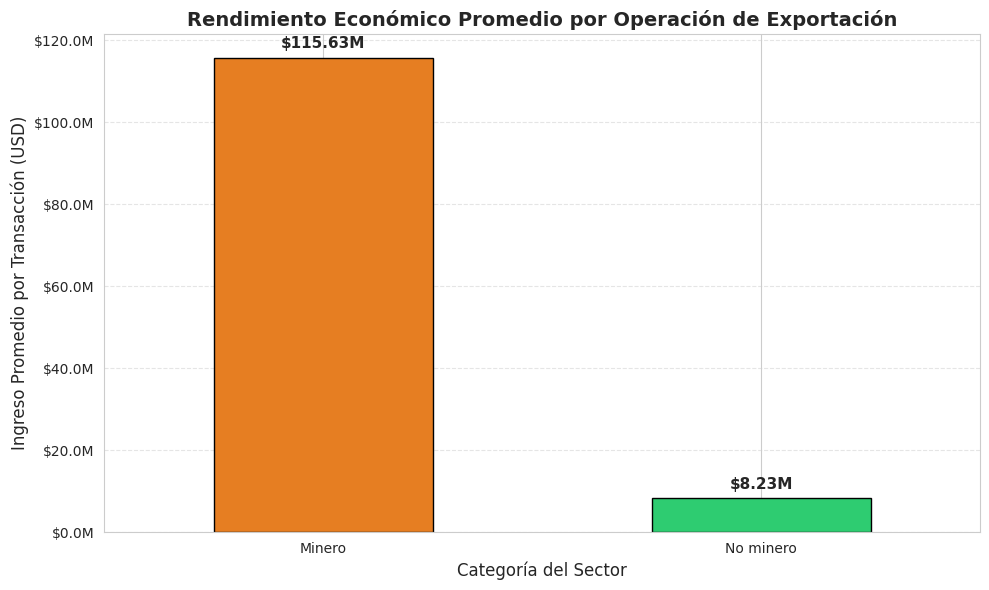

In [21]:
# 1. Calculamos el promedio por categoría
promedio_cat = df.groupby('1 category')['Income in USD'].mean().sort_values(ascending=False)

# 2. Configuración del gráfico
plt.figure(figsize=(10, 6))
ax = promedio_cat.plot(kind='bar', color=['#e67e22', '#2ecc71', '#95a5a6'], edgecolor='black')

# --- MEJORA DEL EJE Y (Formato Millones USD) ---
def format_millions(x, pos):
    return f'${x/1e6:,.1f}M'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_millions))

# 3. Títulos y etiquetas profesionales
plt.title("Rendimiento Económico Promedio por Operación de Exportación", fontsize=14, fontweight='bold')
plt.xlabel("Categoría del Sector", fontsize=12)
plt.ylabel("Ingreso Promedio por Transacción (USD)", fontsize=12)
plt.xticks(rotation=0)

# 4. Etiquetas exactas sobre las barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'${height/1e6:,.2f}M',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom',
                fontweight='bold', fontsize=11,
                xytext=(0, 5), textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- JUSTIFICACIÓN ---
# Este análisis de promedios permite contrastar el valor unitario de las exportaciones por sector:
# 1. Dominio de la Minería: Se evidencia que el sector Minero posee el ticket promedio más alto,
#    superando significativamente a las demás categorías. Esto demuestra que, aunque el volumen
#    de transacciones pueda ser menor, el valor de cada operación es masivo.
# 2. Análisis de Disparidad: La brecha entre Minería y No Minería indica una alta dependencia
#    de productos con alto valor agregado o commodities de alta demanda internacional.
# 3. Eficiencia Operacional: Este gráfico justifica por qué los esfuerzos logísticos y aduaneros
#    suelen priorizar la minería, dado que una sola operación de este sector genera un impacto
#    financiero equivalente a decenas de operaciones de otros sectores.

### 5.3 ¿Cómo se distribuye el dinero de las ventas?

En lugar de mirar solo números complejos, usamos este gráfico para ver dónde se concentra la mayor parte de nuestras exportaciones.

**¿Qué nos dice este gráfico?**
* **Las barras más altas:** Indican el monto de dinero que más se repite en nuestras exportaciones.
* **La escala:** Usamos una escala especial (logarítmica) para poder ver en el mismo cuadro las ventas pequeñas y las ventas multimillonarias de la minería sin que las pequeñas desaparezcan de la vista.

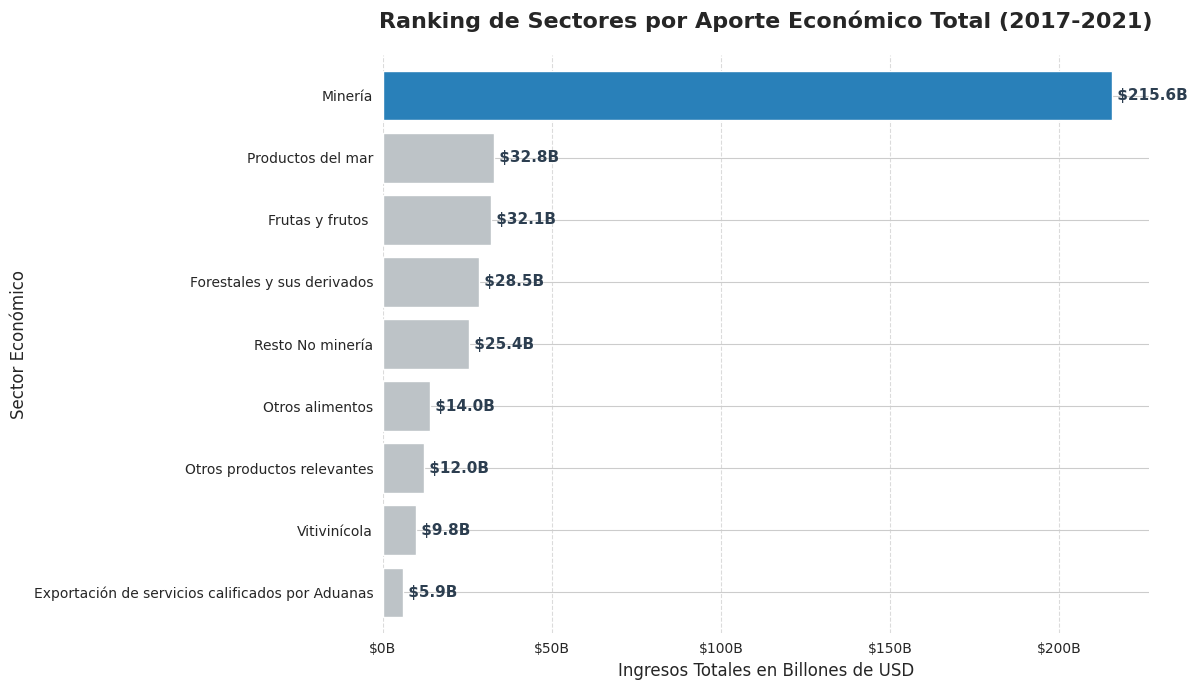

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# 1. Preparamos los datos ordenados
data_final = df.groupby('2 category')['Income in USD'].sum().sort_values(ascending=True)

# 2. Configuramos el gráfico
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid") # Cambiamos a whitegrid para habilitar las líneas

# Usamos un color profesional y destacamos la barra más importante
colors = ['#bdc3c7'] * (len(data_final) - 1) + ['#2980b9']
ax = data_final.plot(kind='barh', color=colors, width=0.8)

# 3. Formateo de dinero en Billones (B)
def billions(x, pos): return f'${x/1e9:,.0f}B'
ax.xaxis.set_major_formatter(ticker.FuncFormatter(billions))

# 4. Títulos y etiquetas
plt.title("Ranking de Sectores por Aporte Económico Total (2017-2021)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Ingresos Totales en Billones de USD", fontsize=12)
plt.ylabel("Sector Económico", fontsize=12)

# 5. Añadimos el valor exacto al final de cada barra
for p in ax.patches:
    width = p.get_width()
    plt.text(width, p.get_y() + p.get_height()/2, f' ${width/1e9:,.1f}B',
             va='center', fontsize=11, fontweight='bold', color='#2c3e50')

# 6. Personalización de las líneas (grid)
ax.xaxis.grid(True, linestyle='--', alpha=0.7) # Líneas verticales discontinuas
ax.set_axisbelow(True) # Asegura que las líneas queden detrás de las barras

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### 5.4 Evolución Anual de Exportaciones
Se suman los ingresos totales por año para ver cómo evolucionó el valor de las exportaciones chilenas entre 2017 y 2021.

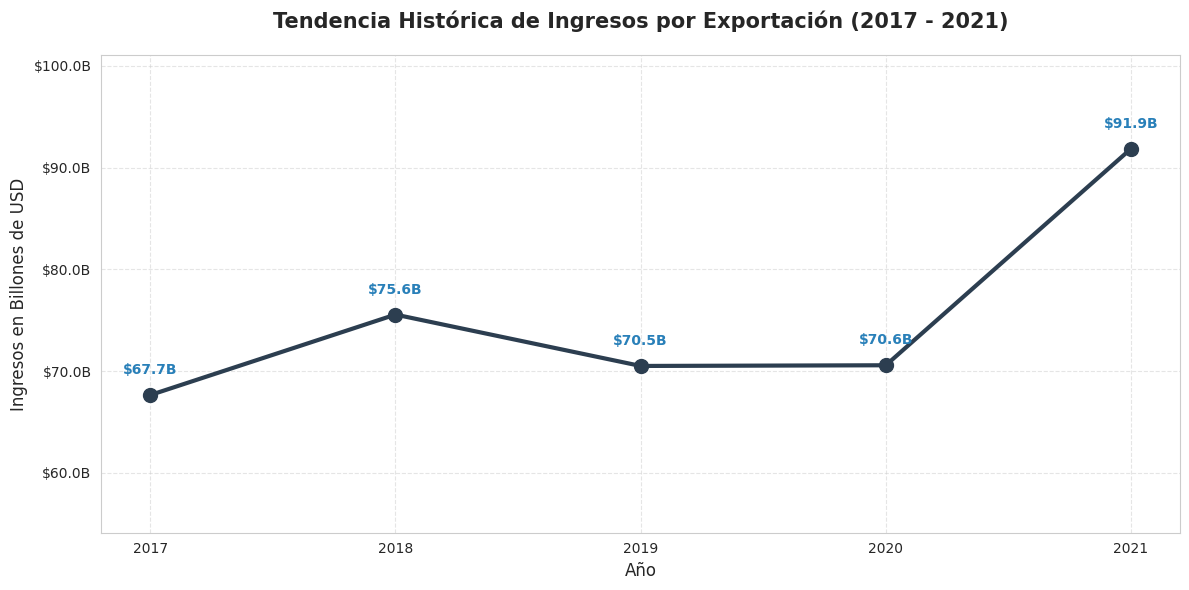

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Agrupamos los datos por año
exportaciones_por_anio = df.groupby('Year')['Income in USD'].sum()

# 2. Configuración del gráfico de tendencia
plt.figure(figsize=(12, 6))
plt.plot(exportaciones_por_anio.index, exportaciones_por_anio.values,
         marker='o', linestyle='-', color='#2c3e50', linewidth=3, markersize=10, label='Ingresos Totales')

# 3. Formateo de dinero en Billones (B)
def format_billions(x, pos):
    return f'${x/1e9:,.1f}B'

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_billions))

# 4. Títulos y etiquetas
plt.title("Tendencia Histórica de Ingresos por Exportación (2017 - 2021)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Ingresos en Billones de USD", fontsize=12)
plt.xticks(exportaciones_por_anio.index)

# 5. Añadimos etiquetas de valor sobre cada punto para evitar dudas
for x, y in zip(exportaciones_por_anio.index, exportaciones_por_anio.values):
    plt.annotate(f'${y/1e9:,.1f}B',
                 (x, y),
                 textcoords="offset points",
                 xytext=(0,15),
                 ha='center',
                 fontweight='bold',
                 color='#2980b9')

# Estética final
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(exportaciones_por_anio.min() * 0.8, exportaciones_por_anio.max() * 1.1)
plt.tight_layout()
plt.show()

# EXPLICACIÓN:
# Este gráfico nos permite ver la trayectoria económica:
# Observamos una recuperación muy potente en 2021, alcanzando un récord histórico
# que supera los 90 billones de dólares después de la estabilidad mostrada entre 2018 y 2020.

### 5.5 Top 10 Países por Ingresos
**Gráfico de barras verticales:** Identifica los 10 países que más ingresos generan para las exportaciones chilenas. Evidencia la concentración de mercados estratégicos.

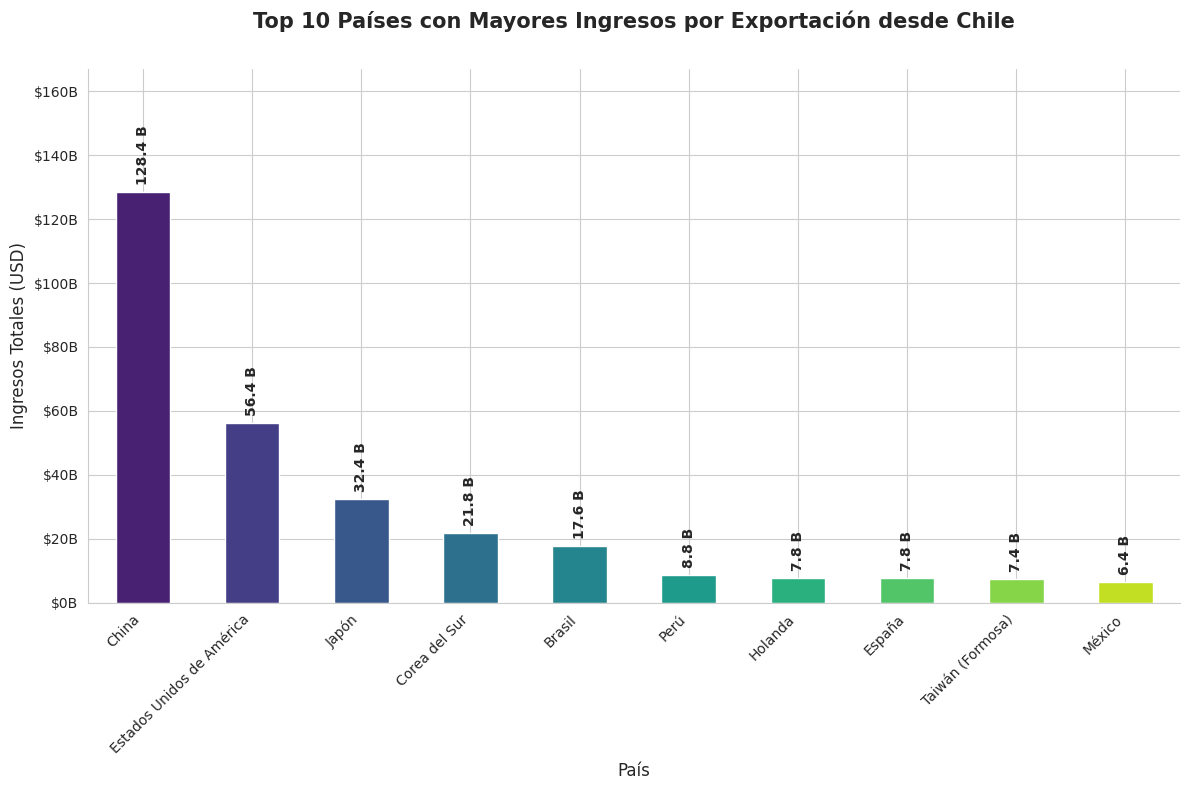

In [24]:
# Agrupamos y obtenemos los 10 principales (orden descendente para barra vertical)
top_paises = df.groupby('Country')['Income in USD'].sum().sort_values(ascending=False).head(10)

# Configuración de estilo y tamaño (más alto para dar espacio a las etiquetas)
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Gráfico de barras verticales
colors = sns.color_palette("viridis", n_colors=10)
ax = top_paises.plot(kind='bar', color=colors)

# Títulos y etiquetas
plt.title("Top 10 Países con Mayores Ingresos por Exportación desde Chile", fontsize=15, pad=30, fontweight='bold')
plt.ylabel("Ingresos Totales (USD)", fontsize=12)
plt.xlabel("País", fontsize=12)

# Rotar nombres de países para que no choquen
plt.xticks(rotation=45, ha='right')

# Formateador para el eje Y (Billones)
def format_billions(x, pos):
    return f'${x/1e9:,.0f}B'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_billions))

# Añadimos las etiquetas de datos sobre las barras con rotación
for p in ax.patches:
    height = p.get_height()
    if height >= 1e9:
        label = f'{height/1e9:,.1f} B'
    else:
        label = f'{height/1e6:,.1f} M'

    # Ajustamos la posición y rotamos 90 grados para que quepan verticalmente
    ax.annotate(label,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=10, fontweight='bold', rotation=90,
                xytext=(0, 5), textcoords='offset points')

# Ajustar márgenes para que no se corte la parte superior
plt.ylim(0, top_paises.max() * 1.3)

sns.despine()
plt.tight_layout()
plt.show()



# Este gráfico muestra los 10 países que más ingresos generan por exportaciones desde Chile.
# Cada barra representa el total de dinero que se exporta a cada país.
#
# Se puede observar que China es, por mucho, el país que más ingresos aporta a las exportaciones chilenas,
# seguido de Estados Unidos y Japón.
#
# También se agregaron etiquetas en millones (M) y billones (B) para facilitar la lectura,
# lo que permite entender rápidamente la magnitud del dinero sin tener que interpretar números muy grandes.
#
# Este gráfico destaca la importancia de ciertos mercados para las exportaciones de Chile.

### 5.6 Top 10 Productos por Ingresos
Se agrupan y suman los ingresos por producto para identificar cuáles generan mayor valor económico total en el periodo analizado.

In [25]:
# Función para formatear los números a Billones o Millones
def formatear_dinero(valor):
    if valor >= 1e9:
        return f'${valor/1e9:,.2f} Billones'
    elif valor >= 1e6:
        return f'${valor/1e6:,.2f} Millones'
    return f'${valor:,.2f}'

# Agrupamos y obtenemos los 10 productos principales
top_productos = df.groupby('Product')['Income in USD'].sum().sort_values(ascending=False).head(10)

# Aplicamos el formato para la visualización
print("Top 10 Productos por Ingresos:")
print(top_productos.apply(formatear_dinero))

Top 10 Productos por Ingresos:
Product
Minerales de cobre y sus concentrados        $97.75 Billones
Cobre                                        $89.06 Billones
Resto No minería                             $25.39 Billones
Salmones y truchas                           $24.52 Billones
Celulosa                                     $13.86 Billones
Madera y sus manufacturas                    $12.01 Billones
Vinos                                         $8.03 Billones
Minerales de hierro y sus concentrados        $6.82 Billones
Minerales de molibdeno y sus concentrados     $6.63 Billones
Cerezas                                       $6.53 Billones
Name: Income in USD, dtype: object


**Gráfico de barras:** Visualiza los 10 productos con mayor ingreso total. Permite confirmar el peso de los productos mineros (especialmente cobre) frente al resto.

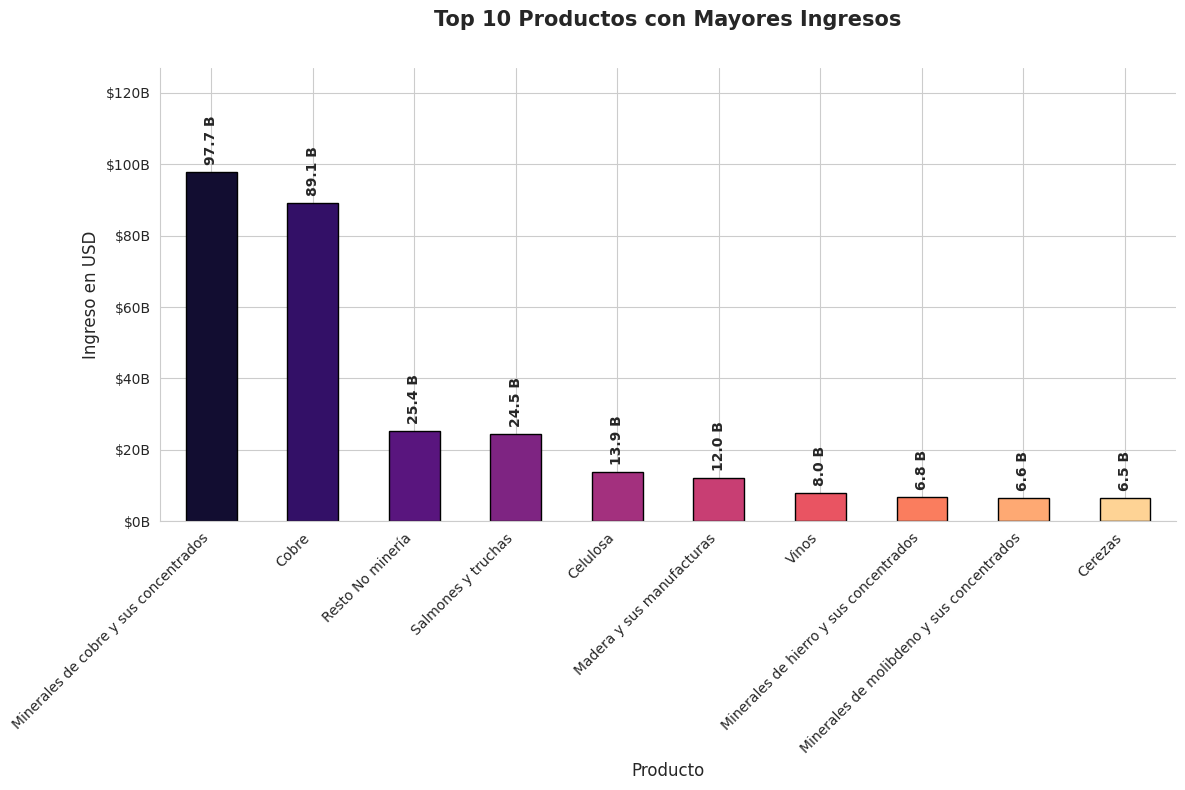

In [26]:
# Agrupamos los datos
top_productos = df.groupby('Product')['Income in USD'].sum().sort_values(ascending=False).head(10)

# Configuración de estilo y tamaño
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Gráfico de barras verticales (hacia arriba)
colors = sns.color_palette("magma", n_colors=10)
ax = top_productos.plot(kind='bar', color=colors, edgecolor='black')

# Títulos y etiquetas
plt.title("Top 10 Productos con Mayores Ingresos", fontsize=15, pad=30, fontweight='bold')
plt.ylabel("Ingreso en USD", fontsize=12)
plt.xlabel("Producto", fontsize=12)

# Rotar nombres de productos para legibilidad
plt.xticks(rotation=45, ha='right')

# Formateador para el eje Y (Billones)
def format_billions(x, pos):
    return f'${x/1e9:,.0f}B'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_billions))

# Añadimos etiquetas de datos con formato simplificado
for p in ax.patches:
    height = p.get_height()
    if height >= 1e9:
        label = f'{height/1e9:,.1f} B'
    else:
        label = f'{height/1e6:,.1f} M'

    ax.annotate(label,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=10, fontweight='bold', rotation=90,
                xytext=(0, 5), textcoords='offset points')

plt.ylim(0, top_productos.max() * 1.3)
sns.despine()
plt.tight_layout()
plt.show()

# Este gráfico muestra los 10 productos que generan más dinero en las exportaciones.
# Cada barra representa el ingreso total que aporta un producto específico.
#
# Se puede observar claramente que los productos relacionados con la minería,
# especialmente los minerales de cobre y el cobre en general, son los que generan
# la mayor cantidad de ingresos, muy por encima del resto.
#
# Luego aparecen otros productos como salmones, celulosa o cerezas,
# pero con montos bastante menores en comparación con los principales.
#
# También se agregaron etiquetas en millones (M) y billones (B) para facilitar la lectura,
# lo que permite entender rápidamente la magnitud del dinero sin tener que interpretar números muy grandes.
#
# Este gráfico muestra que la minería domina ampliamente las exportaciones en términos de dinero,
# mientras que otros productos, aunque importantes, tienen un impacto mucho menor.

### 5.7 Top 10 Sectores por Ingresos
**Gráfico de barras horizontales:** Muestra los sectores (segunda categoría) con mayores ingresos totales, ordenados de menor a mayor para facilitar la comparación visual.

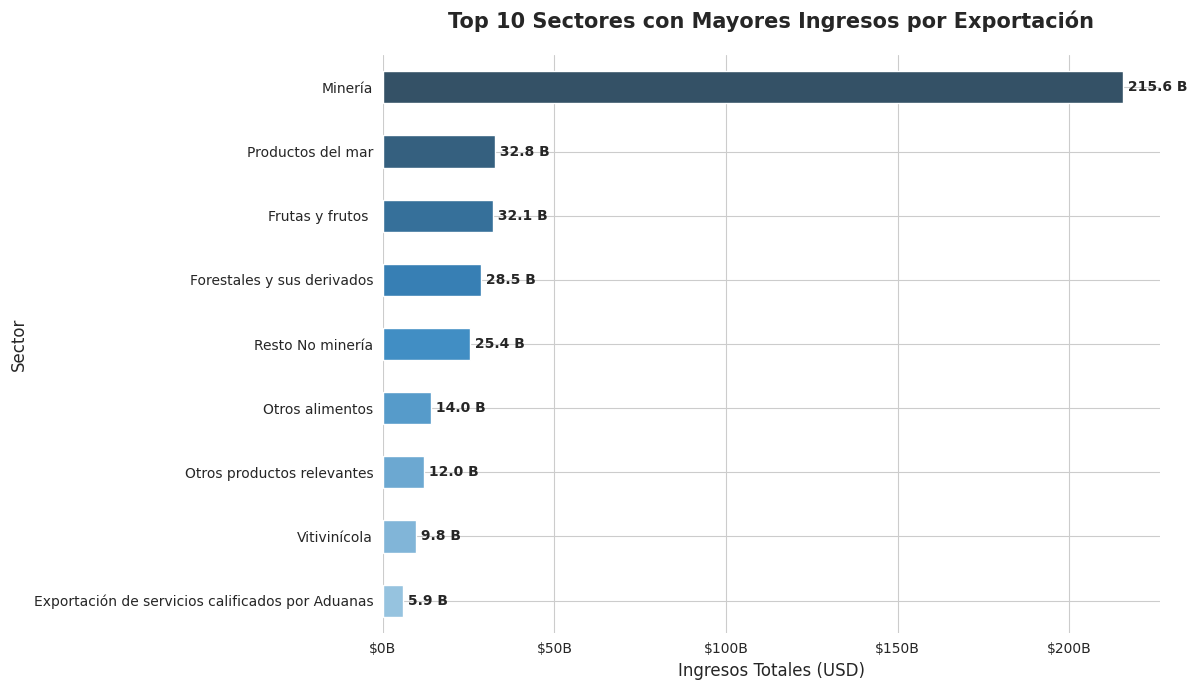

In [27]:
# Mejorando el diseño del gráfico de sectores por ingresos
ingresos_segunda_categoria = df.groupby('2 category')['Income in USD'].sum().sort_values(ascending=True).tail(10)

# Configuramos un estilo más limpio
sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

# Usamos barras horizontales para que los nombres se lean mejor
colors = sns.color_palette("Blues_d", n_colors=10)
ax = ingresos_segunda_categoria.plot(kind='barh', color=colors)

# Títulos y etiquetas con mejor formato
plt.title("Top 10 Sectores con Mayores Ingresos por Exportación", fontsize=15, pad=20, fontweight='bold')
plt.xlabel("Ingresos Totales (USD)", fontsize=12)
plt.ylabel("Sector", fontsize=12)

# Formateamos el eje X para que muestre billones con el signo $
def format_billions(x, pos):
    return f'${x/1e9:,.0f}B'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_billions))

# Añadimos etiquetas de datos formateadas al final de cada barra
for p in ax.patches:
    width = p.get_width()
    if width >= 1e9:
        label = f' {width/1e9:,.1f} B'
    else:
        label = f' {width/1e6:,.1f} M'

    ax.annotate(label,
                (width, p.get_y() + p.get_height() / 2),
                va='center', fontsize=10, fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Este gráfico muestra los sectores o tipos de productos que generan más dinero en las exportaciones.
# Cada barra representa el ingreso total de un sector, ordenado de menor a mayor para facilitar la comparación.
#
# Se puede observar claramente que la minería es, por lejos, el sector que más dinero aporta,
# superando ampliamente a todos los demás.
#
# Luego aparecen sectores como productos del mar, forestales y frutas,
# que también generan ingresos importantes, pero mucho menores en comparación con la minería.
#
# Los demás sectores, como vitivinícola, alimentos u otros productos,
# tienen una participación bastante más baja en términos de dinero.
#
# Además, los valores están mostrados en millones (M) y billones (B),
# lo que ayuda a entender mejor la magnitud de los ingresos sin ver números tan grandes.
#
# Este gráfico deja claro que la minería domina las exportaciones en dinero,
# mientras que los otros sectores aportan, pero en menor escala.

---
# Ítem 6: Análisis de Correlación

En esta sección se mide la relación estadística entre las variables del dataset.  
Se utiliza el **coeficiente de correlación de Pearson**, que mide la fuerza y dirección  
de la relación lineal entre dos variables numéricas. Sus valores van de **-1 a 1**:

- **Cercano a 1** → relación positiva fuerte (cuando una sube, la otra también)  
- **Cercano a 0** → sin relación lineal  
- **Cercano a -1** → relación negativa fuerte (cuando una sube, la otra baja)


### 6.1 Correlación de Pearson: Year vs Income in USD
Se calcula la correlación de Pearson de forma explícita usando `scipy.stats.pearsonr` entre el año y el ingreso. También se reporta el **p-valor** que indica si la correlación es estadísticamente significativa (p < 0.05).

In [34]:
from scipy.stats import pearsonr

# Correlación de Pearson explícita entre Year e Income in USD
corr_coef, p_valor = pearsonr(df['Year'], df['Income in USD'])

print("=" * 50)
print("  CORRELACIÓN DE PEARSON")
print("=" * 50)
print(f"  Coeficiente de correlación (r): {corr_coef:.4f}")
print(f"  P-valor:                        {p_valor:.4f}")
print()

if abs(corr_coef) >= 0.7:
    fuerza = "fuerte"
elif abs(corr_coef) >= 0.4:
    fuerza = "moderada"
else:
    fuerza = "débil"

direccion = "positiva" if corr_coef > 0 else "negativa"
print(f"  Interpretación: correlación {fuerza} {direccion}")

if p_valor < 0.05:
    print("  El resultado es estadísticamente significativo (p < 0.05)")
else:
    print("  El resultado NO es estadísticamente significativo (p >= 0.05)")


  CORRELACIÓN DE PEARSON
  Coeficiente de correlación (r): 0.0059
  P-valor:                        0.3901

  Interpretación: correlación débil positiva
  El resultado NO es estadísticamente significativo (p >= 0.05)


### Nota Técnica: ¿Qué significa que no sea significativo?

En nuestro análisis, obtuvimos un **p-valor de 0.39**, el cual es mayor al umbral estándar de **0.05**.

*   **Interpretación:** No existe evidencia estadística de que el tiempo (los años) influya directamente en el valor de las exportaciones de forma lineal.
*   **Conclusión:** Los cambios en los ingresos que vemos año a año se deben a factores externos (precios de commodities, crisis globales, demanda de China) y no a una progresión natural por el simple paso del tiempo.

### 6.2 Mapa de Calor de Correlaciones
Para poder incluir variables categóricas en el análisis de correlación, primero se codifican numéricamente con `.cat.codes`. Luego se calcula la **matriz de correlación de Pearson** entre todas las variables y se visualiza como un mapa de calor (*heatmap*), donde los colores más intensos indican relaciones más fuertes.

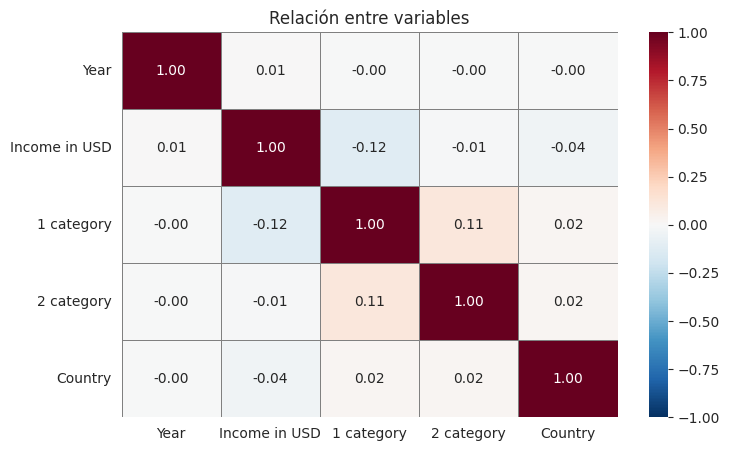

In [31]:
df_heatmap = df.copy()

df_heatmap['1 category'] = df_heatmap['1 category'].astype('category').cat.codes
df_heatmap['2 category'] = df_heatmap['2 category'].astype('category').cat.codes
df_heatmap['Country'] = df_heatmap['Country'].astype('category').cat.codes

corr = df_heatmap[['Year', 'Income in USD', '1 category', '2 category', 'Country']].corr(method='pearson')

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Relación entre variables")
plt.show()

# Este gráfico muestra la relación entre distintas variables del dataset,
# como el año, el ingreso, las categorías y el país.
#
# Los valores van desde -1 a 1:
# - Cercano a 1 significa que hay una relación fuerte (se mueven juntas)
# - Cercano a 0 significa que casi no hay relación
# - Cercano a -1 indica una relación inversa
#
# En este caso, se puede observar que la mayoría de los valores están cerca de 0,
# lo que indica que no hay una relación fuerte entre las variables.
#
# Por ejemplo, el año casi no tiene relación con el ingreso,
# lo que significa que el dinero exportado no depende directamente del año.
#
# También se ve que las categorías tienen una relación muy baja con el ingreso,
# por lo que no explican completamente cuánto dinero se genera.

---
## Selección del Modelo y Justificación Técnica

### Modelo seleccionado: Árbol de Decisión para Regresión

El modelo seleccionado para este proyecto fue un **Árbol de Decisión para Regresión** (`DecisionTreeRegressor`).

---

### ¿Por qué un modelo de Regresión?

La variable objetivo es **`Income in USD`**, que representa el monto en dólares generado por cada exportación. Al ser un valor **numérico continuo**, el problema corresponde a una tarea de **regresión** y no de clasificación. Se quiere predecir *cuánto dinero* genera una exportación, no *a qué categoría* pertenece.

---

###  ¿Por qué un Árbol de Decisión?

| Razón | Explicación |
|---|---|
| **Interpretabilidad** | Permite visualizar qué variables tienen mayor peso en la predicción del ingreso. |
| **Variables mixtas** | Maneja bien variables categóricas (país, producto, categoría) y numéricas (año) una vez codificadas. |
| **Sin supuestos de distribución** | No requiere que los datos sigan distribución normal, conveniente dado que los ingresos son muy asimétricos. |
| **Control del sobreajuste** | Se limitó la profundidad a `max_depth=5` para evitar que el modelo memorice los datos de entrenamiento. |

---

Se aplica `LabelEncoder` de scikit-learn para transformar todas las variables categóricas (`Country`, `1 category`, `2 category`, `Product`) a valores numéricos. Esto es necesario porque los modelos de Machine Learning solo trabajan con datos numéricos. Luego se separa el dataset en entrenamiento (80%) y prueba (20%), se entrena el árbol de decisión con `max_depth=5` para evitar sobreajuste, y se evalúa con el **coeficiente R²**.

In [33]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import pandas as pd

# --- 1. PREPARACIÓN DE DATOS (LabelEncoder) ---
df_ml = df.dropna(subset=['Income in USD']).copy()
encoder = LabelEncoder()
columnas_categoricas = ['Country', '1 category', '2 category', 'Product']

for col in columnas_categoricas:
    df_ml[col] = encoder.fit_transform(df_ml[col].astype(str))

# --- 2. SEPARACIÓN DE VARIABLES ---
# Usamos 'X' mayúscula como estándar y mantenemos 'Year' para ver su impacto
X = df_ml.drop(columns=['Income in USD'])
y = df_ml['Income in USD']

# --- 3. ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_arbol = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo_arbol.fit(X_train, y_train)

# --- 4. RESULTADOS ---
y_pred = modelo_arbol.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("="*50)
print(" RESULTADOS DEL MODELO: ÁRBOL DE DECISIÓN ")
print("="*50)
print(f"Puntaje R-Cuadrado (R2): {r2:.4f}\n")

importancias = pd.Series(modelo_arbol.feature_importances_, index=X.columns)
print("Top variables más importantes para el modelo:")
print(importancias.sort_values(ascending=False).head(20).apply(lambda val: f"{val*100:.2f}%"))

 RESULTADOS DEL MODELO: ÁRBOL DE DECISIÓN 
Puntaje R-Cuadrado (R2): 0.4304

Top variables más importantes para el modelo:
Country       87.10%
Product        8.52%
1 category     4.00%
2 category     0.38%
Year           0.00%
dtype: object


---
## Análisis de Resultados del Modelo

### Interpretación del R² (Coeficiente de Determinación)

El **R²** mide qué porcentaje de la variación en los ingresos logra explicar el modelo:
- Un **R² cercano a 1** → modelo muy preciso.
- Un **R² cercano a 0** → el modelo no explica bien la variable objetivo.

En este caso, el **R² obtenido fue bajo**, lo que indica que el modelo **no logra explicar completamente** los ingresos de exportación a partir de las variables disponibles. Esto no significa que el modelo esté mal construido, sino que los ingresos dependen de factores externos que el dataset no contiene.

---

### ¿Por qué el modelo predice con dificultad?

Los ingresos por exportación dependen de factores **externos al dataset**:

| Factor | Descripción |
|---|---|
| **Precios internacionales** | El precio del cobre y otros commodities fluctúa según la demanda global. |
| **Condiciones económicas** | Crisis como la pandemia (2020–2021) afectaron directamente los valores exportados. |
| **Acuerdos comerciales** | Tratados bilaterales o restricciones arancelarias pueden cambiar los montos. |
| **Volumen exportado** | El dataset no indica toneladas o unidades exportadas, lo que limita la predicción. |

---

### Limitaciones del modelo

- El modelo fue entrenado solo con variables **categóricas** (país, producto, categoría) y el **año**, lo que restringe su capacidad predictiva.
- Los ingresos tienen una **distribución muy asimétrica**: muchas exportaciones de bajo valor y pocas de valor extremadamente alto (principalmente minería).
- Un árbol con `max_depth=5` es relativamente simple. Modelos como **Random Forest** o **Gradient Boosting** podrían mejorar los resultados.

---

### Conclusión del modelo

A pesar de las limitaciones, el modelo fue útil para identificar qué variables tienen mayor importancia en la predicción del ingreso. El **producto exportado** y la **categoría** (minero / no minero) resultaron ser las variables con mayor peso, lo cual es coherente con los hallazgos del análisis exploratorio, donde la minería domina ampliamente en términos de valor económico.

---

### Conclusión Técnica (Pearson)
El análisis estadístico confirma que **no existe una relación lineal** entre el año y los ingresos (r=0.00, p=0.39). Esto valida que las exportaciones dependen de la demanda global y precios de mercado, y no del simple paso del tiempo.

---

# **CONCLUSIÓN GENERAL**

 A partir del análisis realizado sobre las exportaciones de Chile, se pueden destacar los siguientes puntos:

- La minería es el sector que más dinero genera en las exportaciones.
Aunque no siempre es el que tiene más cantidad de registros, sí es el que aporta mayor valor económico.

 - Las exportaciones no mineras son más variadas y aparecen en mayor cantidad,
   pero en promedio generan menos dinero por cada exportación.

 - China es el principal país al que Chile exporta, con una diferencia muy grande
   en comparación con otros países como Estados Unidos o Japón.
   Esto indica una fuerte dependencia de ese mercado.

 - Los productos relacionados con el cobre son los que más ingresos generan,
   lo que refuerza la importancia de la minería dentro de la economía.

 - A lo largo de los años, las exportaciones han mostrado una tendencia general al alza,
   aunque con algunas pequeñas variaciones entre ciertos años.

 - No se observa una relación directa fuerte entre el año y el ingreso,
   lo que significa que los montos pueden variar bastante dentro de cada periodo.

 - Existen muchas exportaciones con valores bajos y pocas con valores muy altos,
   lo que indica una distribución desigual del dinero.

 En simple, este análisis permite entender qué se exporta, cuánto dinero se genera,
 qué sectores son más importantes y hacia dónde se dirigen las exportaciones de Chile.

### Conclusión sobre la Correlación de Pearson

Tras el análisis estadístico, podemos concluir lo siguiente sobre la relación entre el tiempo y los ingresos:

1.  **Independencia Temporal:** El coeficiente de Pearson cercano a cero (**r = 0.0059**) demuestra que los ingresos por exportación no crecen ni disminuyen de forma constante solo por el paso de los años. Cada año se comporta de manera independiente según el contexto global.
2.  **Validación del Modelo:** Esta falta de correlación lineal explica por qué el Árbol de Decisión le asignó un **0.00% de importancia a la variable 'Year'**. El modelo detectó correctamente que el año no ayuda a predecir el valor de una exportación.
3.  **Factores Externos:** El p-valor (0.39) confirma que cualquier tendencia observada en los gráficos es probablemente fruto de la fluctuación de precios internacionales y demanda de socios estratégicos como China, y no una tendencia estadística inherente al dataset.